In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/groups/knowles_lab/data/sc/pbmc/Leaflet/"

The junctions are loaded from the following path: /gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/
The files in the path are: ['PBMC1', 'PBMC2']


In [2]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_junctions

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/groups/knowles_lab/Karin/genome_files/gencode.v43.basic.annotation.gtf" 

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "PBMC_intron_clusters"
junc_bed_file= output_path + "PBMC_juncs_all_tissues.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.1 
min_junc_reads = 10
min_num_cells_wjunc = 10
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*junctions_with_barcodes.bed" # depends on how you ran regtools 

### Run intron clustering 

In [3]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,
                       run_notebook = True)

Loading files obtained from single_cell sequencing
Reading in junction files from /gpfs/commons/groups/knowles_lab/data/sc/pbmc/results
The number of junction files to be processed is 813


 59%|█████▊    | 477/813 [00:49<00:19, 17.60it/s]

Could not read in /gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC2/SRR9170182/junctions_with_barcodes.bed: No columns to parse from file


100%|██████████| 813/813 [01:17<00:00, 10.54it/s]


The total number of files that could not be read is 1 as these had no junctions
The gtf file you provided is /gpfs/commons/groups/knowles_lab/Karin/genome_files/gencode.v43.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


Reading gtf file took 119.51 seconds
The number of unique exons is 411865
The number of unique transcript ids is 115526
The number of unique gene ids is 62668
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Cleaning up 'chrom' column
Making gr object from all junctions across all cell types
The number of junctions prior to assessing distance to exons is 263504
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 148559
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 116867
The number of junctions after removing singletons is 148557
The number of clusters after removing singletons is 116866
The number of clusters after filtering for shared splice sites is 13207
The number of junctions after filtering for shared splice sites is 44770
Refining intron clusters to account for junction usage ratio threshold...
Done refining clust

In [4]:
# Load bed file and prep data for visualization
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# dat_vis 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [7]:
# find all junctions in the gene "TP53"
dat_vis_tp53 = dat_vis[dat_vis["gene_name"] == "TP53"]
dat_vis_tp53

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
8052,17,7670715,7673206,-,2491,32,17_7670715_7673206,16105,17,7670715,7673206,-,7670608,7670715,ENSG00000141510.18,TP53,ENST00000504290.5,ENSE00003634848.1
8053,17,7670715,7673534,-,2819,217,17_7670715_7673534,16105,17,7670715,7673534,-,7670608,7670715,ENSG00000141510.18,TP53,ENST00000504290.5,ENSE00003634848.1
8064,17,7673339,7673534,-,195,50,17_7673339_7673534,16105,17,7673339,7673534,-,7673206,7673339,ENSG00000141510.18,TP53,ENST00000510385.5,ENSE00003735852.1


     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
8053    17       7670.715     7673.534      -           2819           217   
8064    17       7673.339     7673.534      -            195            50   
8052    17       7670.715     7673.206      -           2491            32   

       Start_b     End_b            exon_id  
8053  7670.608  7670.715  ENSE00003634848.1  
8064  7673.206  7673.339  ENSE00003735852.1  
8052  7670.608  7670.715  ENSE00003634848.1  
The junction of interest is 17_7670715_7673534


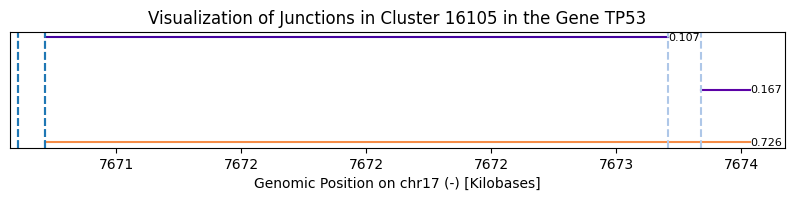

In [8]:
# Get a quick glance at the junctions
#j = all_juncs_df.junction_id.sample(1).values[0]
j = "17_7670715_7673534"
visualize_junctions(dat_vis, j)

### Now let's convert the intron clusters to a format that can be used by LeafletSC )

In [9]:
intron_clusters = "/gpfs/commons/groups/knowles_lab/data/sc/pbmc/Leaflet/PBMC_intron_clusters_50_500000_10_20240313_single_cell.gz" # path to the intron clusters file
output_file = output_path + "PBMC1_PBMC2_intron_clusters_model_input" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [10]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/groups/knowles_lab/data/sc/pbmc/Leaflet/PBMC_intron_clusters_50_500000_10_20240313_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


160it [00:09, 17.43it/s]


Done processing intron clusters
The number of intron clusters evaluated is 8365
The number of junctions evaluated is 24200
The number of cells evaluated is 747
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 747
The number of cells per cell type is:
cell_type
/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC1/SRR9167510/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC1/SRR9167511/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC1/SRR9167512/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC1/SRR9167513/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/data/sc/pbmc/results/PBMC1/SRR9167514/junctions_with_barcodes.bed    1
                                                                                                     ..
/gpfs/commons/groups/knowl